# LG전자 재무 데이터 분석 및 시각화

이 노트북에서는 LG전자의 2014년부터 2024년까지의 재무 데이터를 분석하고 시각화합니다.

## 분석 항목
- 매출
- 매출총이익 
- 영업이익
- EBIT (Earnings Before Interest and Taxes)
- 당기순이익

In [1]:
# 필요한 라이브러리 import
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 그래프 스타일 설정
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

In [21]:
# LG전자 재무 데이터 생성
data = {
    '연도': ['2014(13기)', '2015(14기)', '2016(15기)', '2017(16기)', '2018(17기)', 
           '2019(18기)', '2020(19기)', '2021(20기)', '2022(21기)', '2023(22기)', '2024(23기)'],
    '매출': [59040767000000, 56509008000000, 55367033000000, 61396284000000, 61341664000000, 
           62306175000000, 57176170000000, 73907984000000, 82521459000000, 82262664000000, 87728182000000],
    '매출총이익': [13741645000000, 12873945000000, 13736740000000, 14658721000000, 15081044000000,
                15335569000000, 15345864000000, 18897222000000, 20219385000000, 19801259000000, 21379234000000],
    '영업이익': [1828557000000, 1192291000000, 1337763000000, 2468549000000, 2703291000000,
              2436139000000, 3843381000000, 4057997000000, 3567327000000, 3653294000000, 3419675000000],
    'EBIT': [1218270000000, 593125000000, 721717000000, 2558112000000, 2008575000000,
           528638000000, 3343346000000, 3543395000000, 2570407000000, 2014897000000, 1335795000000],
    '당기순이익': [501357000000, 249143000000, 126315000000, 1869518000000, 1472814000000,
               179948000000, 2063790000000, 1414972000000, 1863123000000, 1150611000000, 591365000000]
}

# DataFrame 생성
df = pd.DataFrame(data)

# 연도 컬럼을 숫자로 변환 (시각화용)
df['연도_숫자'] = [int(year.split('(')[0]) for year in df['연도']]

# 데이터 확인
print("LG전자 재무 데이터:")
print(df.head())
print(f"\n데이터 형태: {df.shape}")
print(f"\n데이터 타입:\n{df.dtypes}")

LG전자 재무 데이터:
          연도              매출           매출총이익           영업이익           EBIT  \
0  2014(13기)  59040767000000  13741645000000  1828557000000  1218270000000   
1  2015(14기)  56509008000000  12873945000000  1192291000000   593125000000   
2  2016(15기)  55367033000000  13736740000000  1337763000000   721717000000   
3  2017(16기)  61396284000000  14658721000000  2468549000000  2558112000000   
4  2018(17기)  61341664000000  15081044000000  2703291000000  2008575000000   

           당기순이익  연도_숫자  
0   501357000000   2014  
1   249143000000   2015  
2   126315000000   2016  
3  1869518000000   2017  
4  1472814000000   2018  

데이터 형태: (11, 7)

데이터 타입:
연도       object
매출        int64
매출총이익     int64
영업이익      int64
EBIT      int64
당기순이익     int64
연도_숫자     int64
dtype: object


In [24]:
# 기본 통계 정보
print("=== LG전자 재무 데이터 기본 통계 ===")
print(df[['매출', '매출총이익', '영업이익', 'EBIT', '당기순이익']].describe())

# 연도별 성장률 계산
financial_metrics = ['매출', '매출총이익', '영업이익', 'EBIT', '당기순이익']
growth_df = df.copy()

for metric in financial_metrics:
    growth_df[f'{metric}_성장률'] = df[metric].pct_change() * 100

print("\n=== 연도별 성장률 (%) ===")
print(growth_df[['연도'] + [f'{metric}_성장률' for metric in financial_metrics]].round(2))

=== LG전자 재무 데이터 기본 통계 ===
                 매출         매출총이익          영업이익          EBIT         당기순이익
count  1.100000e+01  1.100000e+01  1.100000e+01  1.100000e+01  1.100000e+01
mean   6.723249e+13  1.646097e+13  2.773479e+12  1.857843e+12  1.043905e+12
std    1.200559e+13  3.012525e+12  1.014028e+12  1.069204e+12  7.379126e+11
min    5.536703e+13  1.287394e+13  1.192291e+12  5.286380e+11  1.263150e+11
25%    5.810847e+13  1.420018e+13  2.132348e+12  9.699935e+11  3.752500e+11
50%    6.139628e+13  1.533557e+13  2.703291e+12  2.008575e+12  1.150611e+12
75%    7.808532e+13  1.934924e+13  3.610310e+12  2.564260e+12  1.667968e+12
max    8.772818e+13  2.137923e+13  4.057997e+12  3.543395e+12  2.063790e+12

=== 연도별 성장률 (%) ===
           연도  매출_성장률  매출총이익_성장률  영업이익_성장률  EBIT_성장률  당기순이익_성장률
0   2014(13기)     NaN        NaN       NaN       NaN        NaN
1   2015(14기)   -4.29      -6.31    -34.80    -51.31     -50.31
2   2016(15기)   -2.02       6.70     12.20     21.68     -49.30
3   2017(16기)

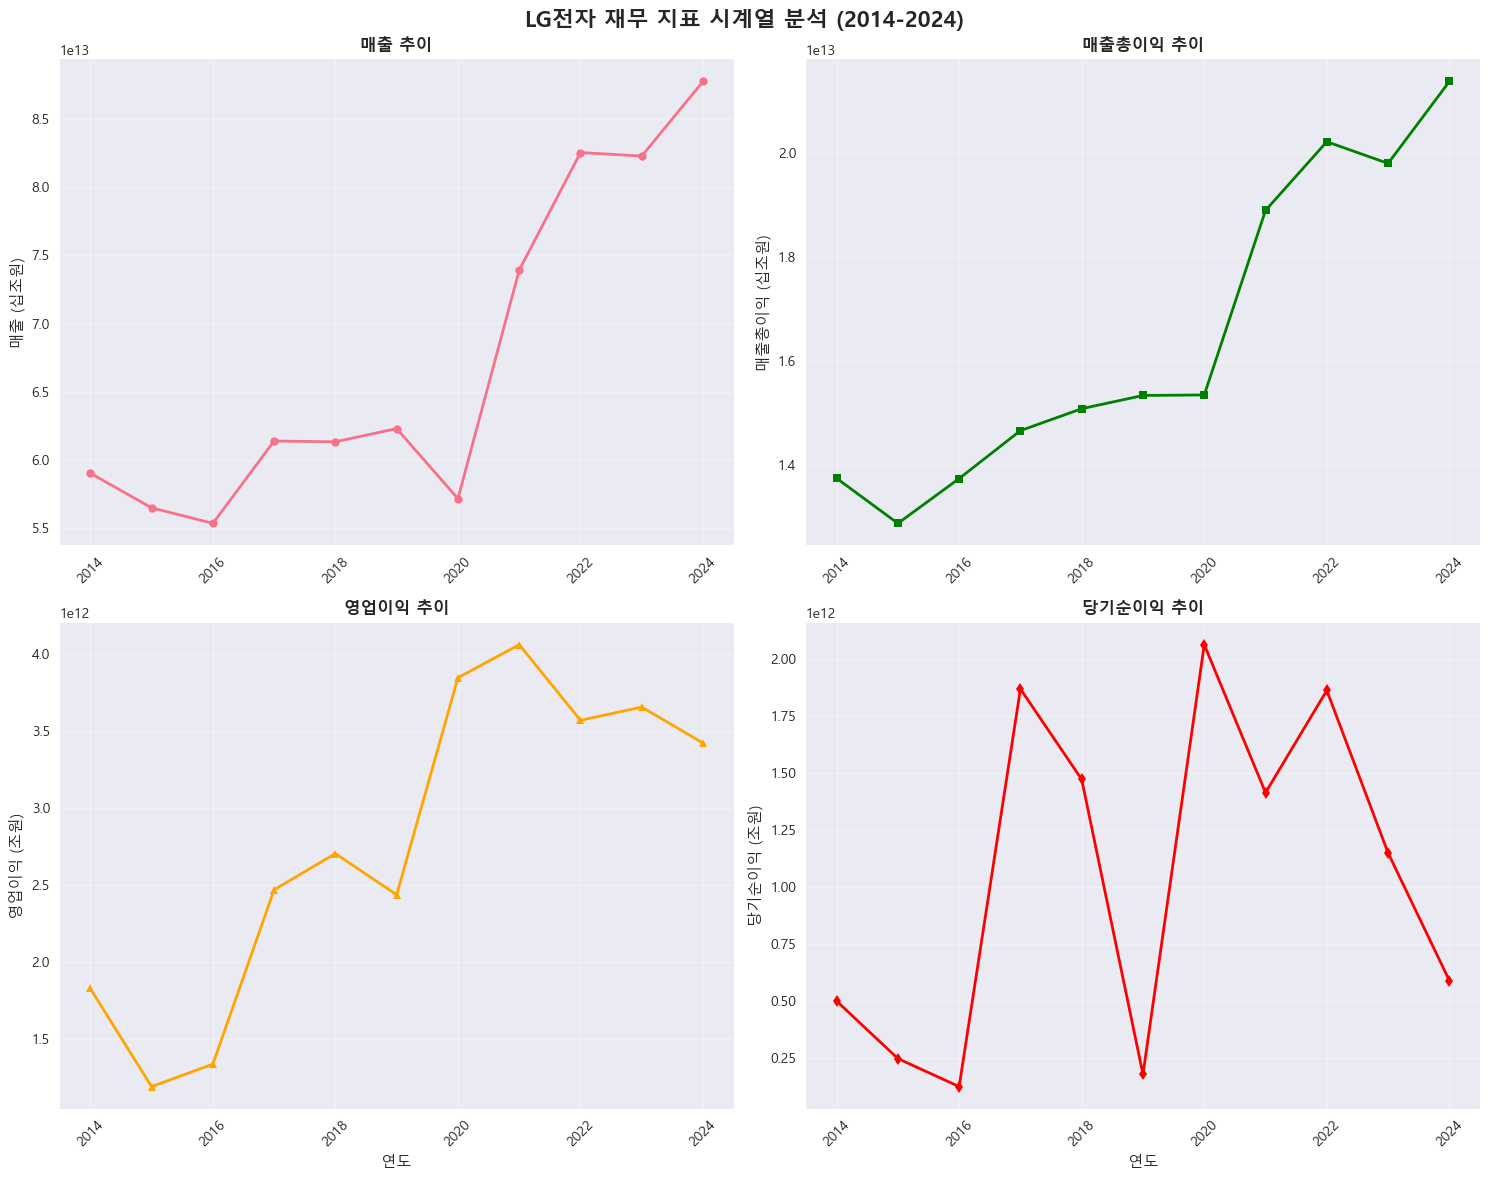

In [27]:
# 1. 연도별 매출 및 주요 지표 시계열 차트 (Matplotlib)
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('LG전자 재무 지표 시계열 분석 (2014-2024)', fontsize=16, fontweight='bold')

# 매출 추이
# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
axes[0, 0].plot(df['연도_숫자'], df['매출'], marker='o', linewidth=2, markersize=6)
axes[0, 0].set_title('매출 추이', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('매출 (십조원)')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].tick_params(axis='x', rotation=45)

# 매출총이익 추이
axes[0, 1].plot(df['연도_숫자'], df['매출총이익'], marker='s', color='green', linewidth=2, markersize=6)
axes[0, 1].set_title('매출총이익 추이', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('매출총이익 (십조원)')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].tick_params(axis='x', rotation=45)

# 영업이익 추이
axes[1, 0].plot(df['연도_숫자'], df['영업이익'], marker='^', color='orange', linewidth=2, markersize=6)
axes[1, 0].set_title('영업이익 추이', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('연도')
axes[1, 0].set_ylabel('영업이익 (조원)')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].tick_params(axis='x', rotation=45)

# 당기순이익 추이
axes[1, 1].plot(df['연도_숫자'], df['당기순이익'], marker='d', color='red', linewidth=2, markersize=6)
axes[1, 1].set_title('당기순이익 추이', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('연도')
axes[1, 1].set_ylabel('당기순이익 (조원)')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

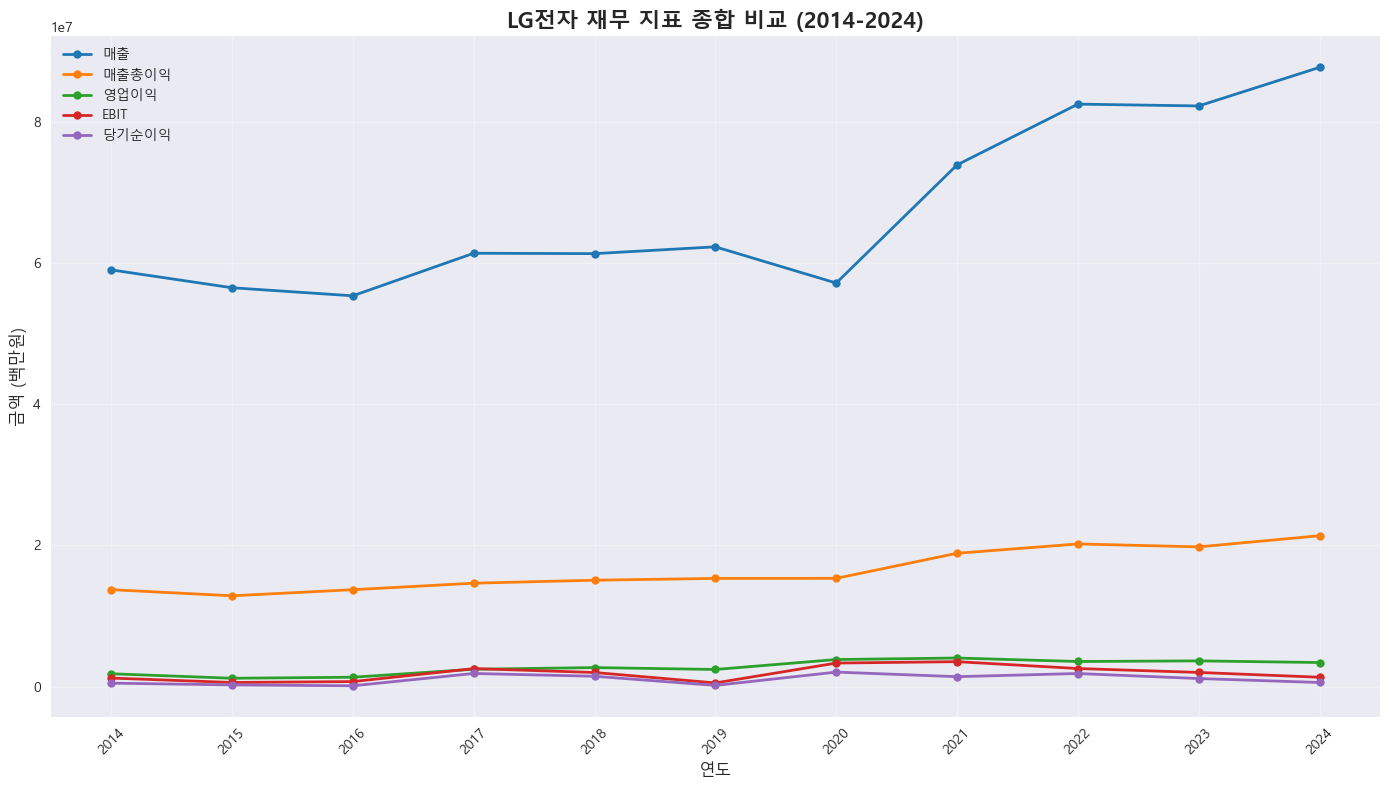

In [12]:
# 2. 모든 재무 지표 비교 (다중 라인 차트)
plt.figure(figsize=(14, 8))

metrics = ['매출', '매출총이익', '영업이익', 'EBIT', '당기순이익']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

for i, metric in enumerate(metrics):
    plt.plot(df['연도_숫자'], df[metric], marker='o', linewidth=2, 
             label=metric, color=colors[i], markersize=6)
             
# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False


plt.title('LG전자 재무 지표 종합 비교 (2014-2024)', fontsize=16, fontweight='bold')
plt.xlabel('연도', fontsize=12)
plt.ylabel('금액 (백만원)', fontsize=12)
plt.legend(loc='upper left', fontsize=10)
plt.grid(True, alpha=0.3)
plt.xticks(df['연도_숫자'], rotation=45)
plt.tight_layout()
plt.show()

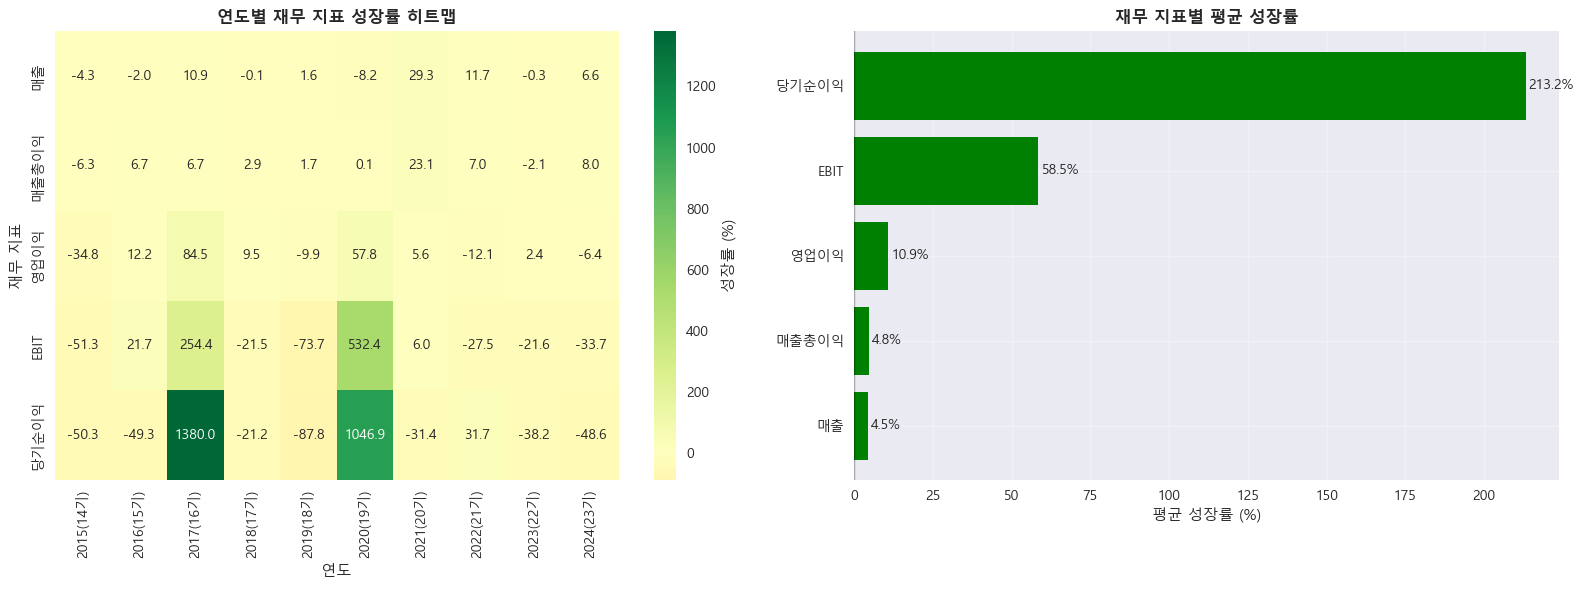

In [13]:
# 3. 연도별 성장률 히트맵
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# 성장률 데이터 준비 (첫 번째 연도 제외)
growth_data = growth_df[['연도'] + [f'{metric}_성장률' for metric in financial_metrics]].iloc[1:]
growth_matrix = growth_data[[f'{metric}_성장률' for metric in financial_metrics]].T

# 히트맵
# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

sns.heatmap(growth_matrix, 
            xticklabels=growth_data['연도'], 
            yticklabels=[metric.replace('_성장률', '') for metric in growth_matrix.index],
            annot=True, fmt='.1f', cmap='RdYlGn', center=0,
            ax=ax1, cbar_kws={'label': '성장률 (%)'})
ax1.set_title('연도별 재무 지표 성장률 히트맵', fontsize=12, fontweight='bold')
ax1.set_xlabel('연도')
ax1.set_ylabel('재무 지표')

# 평균 성장률 막대 차트
avg_growth = growth_df[[f'{metric}_성장률' for metric in financial_metrics]].mean()
avg_growth.index = financial_metrics
avg_growth_sorted = avg_growth.sort_values(ascending=True)

bars = ax2.barh(range(len(avg_growth_sorted)), avg_growth_sorted.values, 
                color=['red' if x < 0 else 'green' for x in avg_growth_sorted.values])
ax2.set_yticks(range(len(avg_growth_sorted)))
ax2.set_yticklabels(avg_growth_sorted.index)
ax2.set_xlabel('평균 성장률 (%)')
ax2.set_title('재무 지표별 평균 성장률', fontsize=12, fontweight='bold')
ax2.axvline(x=0, color='black', linestyle='-', alpha=0.3)
ax2.grid(True, alpha=0.3)

# 값 표시
for i, bar in enumerate(bars):
    width = bar.get_width()
    ax2.text(width + (1 if width > 0 else -1), bar.get_y() + bar.get_height()/2, 
             f'{width:.1f}%', ha='left' if width > 0 else 'right', va='center')

plt.tight_layout()
plt.show()

In [7]:
# 4. Plotly를 이용한 인터랙티브 시각화
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=('매출 추이', '수익성 지표 비교', '연도별 모든 지표', '재무 지표 구성비'),
    specs=[[{"secondary_y": False}, {"secondary_y": False}],
           [{"colspan": 2}, None]],
    vertical_spacing=0.12
)

# 매출 추이
fig.add_trace(
    go.Scatter(x=df['연도'], y=df['매출'], mode='lines+markers',
               name='매출', line=dict(color='blue', width=3)),
    row=1, col=1
)

# 수익성 지표 비교
profit_metrics = ['매출총이익', '영업이익', '당기순이익']
colors_profit = ['green', 'orange', 'red']
for i, metric in enumerate(profit_metrics):
    fig.add_trace(
        go.Scatter(x=df['연도'], y=df[metric], mode='lines+markers',
                   name=metric, line=dict(color=colors_profit[i], width=2)),
        row=1, col=2
    )

# 모든 지표 한 번에
for i, metric in enumerate(financial_metrics):
    fig.add_trace(
        go.Scatter(x=df['연도'], y=df[metric], mode='lines+markers',
                   name=f'{metric}_전체', line=dict(width=2),
                   showlegend=False),
        row=2, col=1
    )

fig.update_layout(
    title_text="LG전자 재무 데이터 인터랙티브 분석",
    title_x=0.5,
    height=600,
    showlegend=True
)

fig.update_xaxes(tickangle=45)
fig.show()

=== 연도별 수익성 비율 ===
           연도  매출총이익률  영업이익률  순이익률
0   2014(13기)   23.27   3.10  0.85
1   2015(14기)   22.78   2.11  0.44
2   2016(15기)   24.81   2.42  0.23
3   2017(16기)   23.88   4.02  3.05
4   2018(17기)   24.59   4.41  2.40
5   2019(18기)   24.61   3.91  0.29
6   2020(19기)   26.84   6.72  3.61
7   2021(20기)   25.57   5.49  1.91
8   2022(21기)   24.50   4.32  2.26
9   2023(22기)   24.07   4.44  1.40
10  2024(23기)   24.37   3.90  0.67


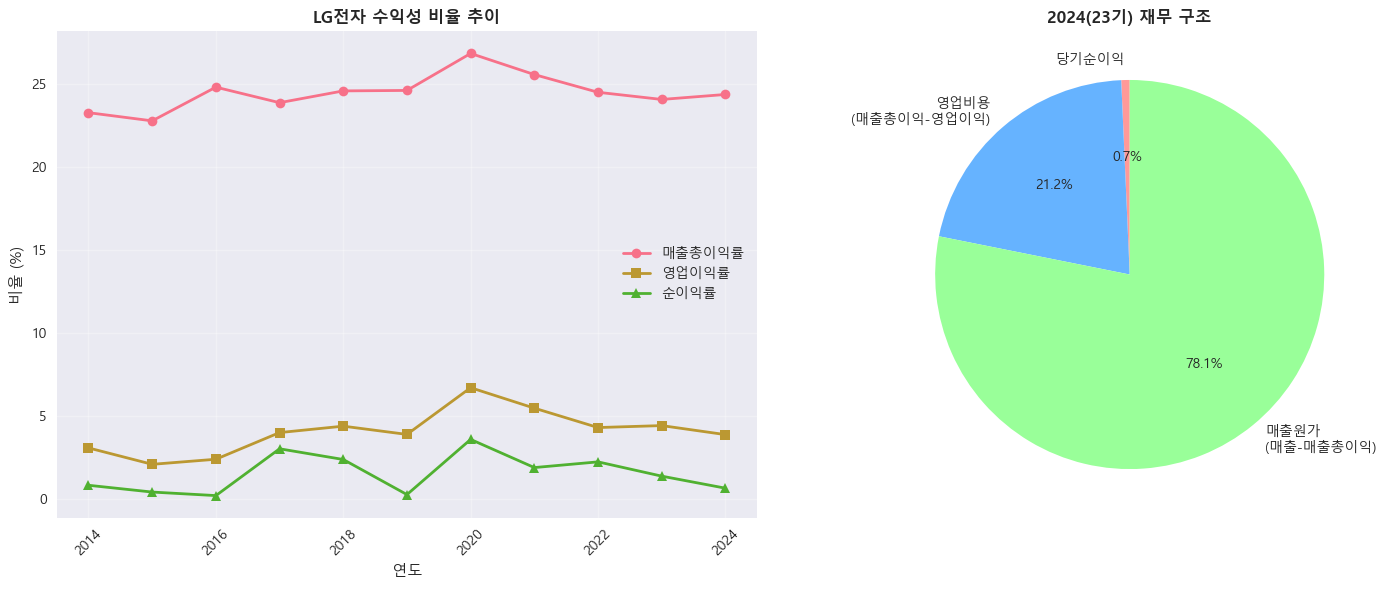

In [14]:
# 5. 재무 비율 분석
# 주요 재무 비율 계산
df['매출총이익률'] = (df['매출총이익'] / df['매출']) * 100
df['영업이익률'] = (df['영업이익'] / df['매출']) * 100
df['순이익률'] = (df['당기순이익'] / df['매출']) * 100

print("=== 연도별 수익성 비율 ===")
ratio_df = df[['연도', '매출총이익률', '영업이익률', '순이익률']].round(2)
print(ratio_df)

# 수익성 비율 시각화

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False


# 수익성 비율 추이
axes[0].plot(df['연도_숫자'], df['매출총이익률'], marker='o', label='매출총이익률', linewidth=2)
axes[0].plot(df['연도_숫자'], df['영업이익률'], marker='s', label='영업이익률', linewidth=2)
axes[0].plot(df['연도_숫자'], df['순이익률'], marker='^', label='순이익률', linewidth=2)
axes[0].set_title('LG전자 수익성 비율 추이', fontsize=12, fontweight='bold')
axes[0].set_xlabel('연도')
axes[0].set_ylabel('비율 (%)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].tick_params(axis='x', rotation=45)

# 2024년 재무 구조 파이 차트
latest_data = df.iloc[-1]
labels = ['당기순이익', '영업비용\n(매출총이익-영업이익)', '매출원가\n(매출-매출총이익)']
values = [
    latest_data['당기순이익'],
    latest_data['매출총이익'] - latest_data['영업이익'],
    latest_data['매출'] - latest_data['매출총이익']
]
colors = ['#ff9999', '#66b3ff', '#99ff99']

axes[1].pie(values, labels=labels, autopct='%1.1f%%', startangle=90, colors=colors)
axes[1].set_title(f'{latest_data["연도"]} 재무 구조', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

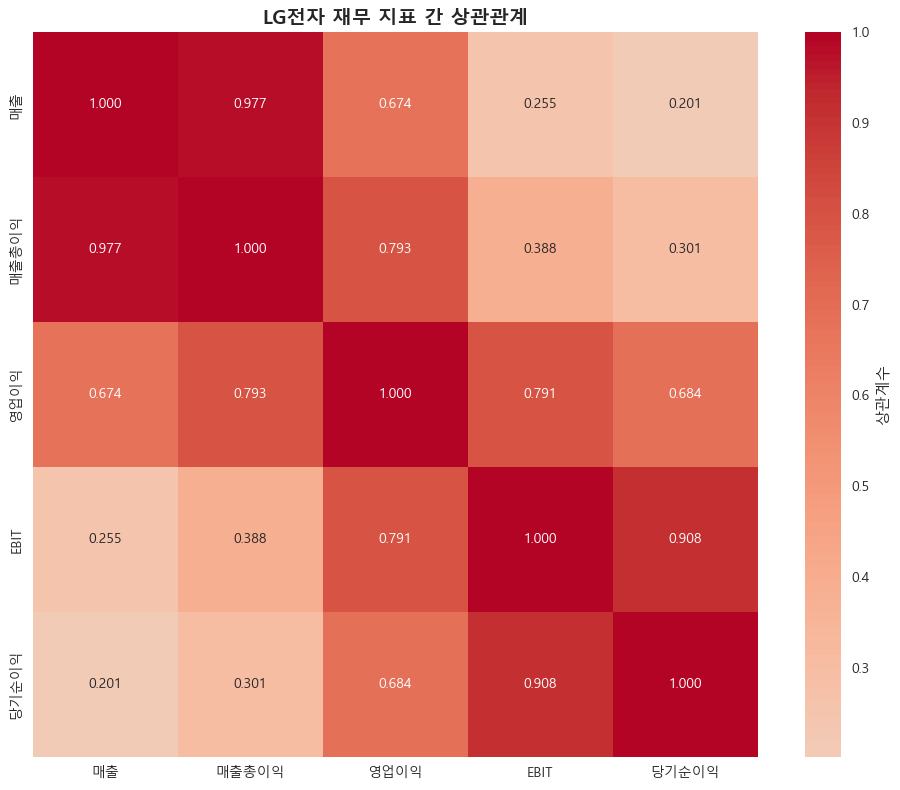

=== 상관관계 분석 결과 ===
높은 양의 상관관계를 보이는 지표들:
매출 ↔ 매출총이익: 0.977
매출총이익 ↔ 영업이익: 0.793
영업이익 ↔ EBIT: 0.791
EBIT ↔ 당기순이익: 0.908

           LG전자 재무 분석 요약
분석 기간: 2014년 ~ 2024년 (11년간)
최고 매출: 87,728,182백만원 (2024(23기))
최저 매출: 55,367,033백만원 (2016(15기))
매출 성장률: 48.6% (2014 대비 2024)
최고 영업이익: 4,057,997백만원 (2021(20기))
최고 당기순이익: 2,063,790백만원 (2020(19기))
평균 영업이익률: 4.08%
평균 순이익률: 1.56%


In [15]:
# 6. 재무 지표 간 상관관계 분석
correlation_matrix = df[financial_metrics].corr()

plt.figure(figsize=(10, 8))
# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, fmt='.3f', cbar_kws={'label': '상관계수'})
plt.title('LG전자 재무 지표 간 상관관계', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("=== 상관관계 분석 결과 ===")
print("높은 양의 상관관계를 보이는 지표들:")
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        corr_value = correlation_matrix.iloc[i, j]
        if corr_value > 0.7:
            print(f"{correlation_matrix.columns[i]} ↔ {correlation_matrix.columns[j]}: {corr_value:.3f}")

# 최종 요약 통계
print("\n" + "="*50)
print("           LG전자 재무 분석 요약")
print("="*50)
print(f"분석 기간: 2014년 ~ 2024년 (11년간)")
print(f"최고 매출: {df['매출'].max():,}백만원 ({df.loc[df['매출'].idxmax(), '연도']})")
print(f"최저 매출: {df['매출'].min():,}백만원 ({df.loc[df['매출'].idxmin(), '연도']})")
print(f"매출 성장률: {((df['매출'].iloc[-1] / df['매출'].iloc[0] - 1) * 100):.1f}% (2014 대비 2024)")
print(f"최고 영업이익: {df['영업이익'].max():,}백만원 ({df.loc[df['영업이익'].idxmax(), '연도']})")
print(f"최고 당기순이익: {df['당기순이익'].max():,}백만원 ({df.loc[df['당기순이익'].idxmax(), '연도']})")
print(f"평균 영업이익률: {df['영업이익률'].mean():.2f}%")
print(f"평균 순이익률: {df['순이익률'].mean():.2f}%")